In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

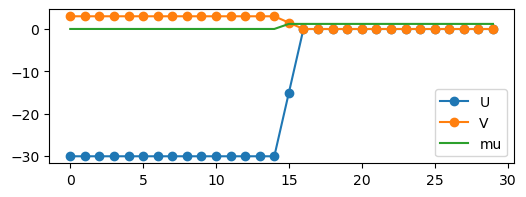

In [2]:
widthN =15
widthP =15

X, Y = widthN+widthP, 60
lattice = Lattice(X, Y)
t = 1
T=0.001

muN = 1.2 * t
muP = 0.01 * t
mu = np.zeros(lattice.X)
mu[:widthP] = muP
mu[widthP:] = muN

U = None
V_prime = None

V0 = 3 * t
V = V0 * np.ones(lattice.X)
V[widthP:] = 0
V[widthP] = V0/2

U0 = -30 * t
U = U0 * np.ones(lattice.X)
U[widthP:] = 0
U[widthP] = U0/2

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, label='mu')
plt.legend()

d:\miniconda3\envs\master-venv\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\miniconda3\envs\master-venv\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


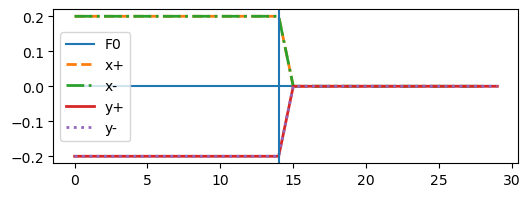

In [3]:
H = Hamiltonian(t, mu, lattice,
                U=U, V_prime=V_prime, g_s=V,
                F_init=[0.2, 0.2, -0.2, -0.2])

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(H.F0, label="F0")
if V is not None:
    plt.plot(np.real(H.F_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.F_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.real(H.F_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.real(H.F_ymin), label="y-", linestyle=':', lw=2)
if V_prime is not None:
    plt.plot(np.real(H.Fuu_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.Fuu_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.Fuu_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.Fuu_ymin), label="y-", linestyle=':', lw=2)
plt.legend()
plt.axvline(widthN-1)

In [4]:
bdg_sc(H, atol=1e-5, rtol=0.01, maxiter=1000, verbose=True, temperature=T, mixing=0.5)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.05878313536878553
Relative error: 58783135368.78553
Average old: 0j
Average: (0.005540962394043556+0j)
F_xplus:
Absolute error: 0.21831871541994122
Relative error: 17956038001.50315
Average old: (0.10344827586206896+0j)
Average: (0.13350093144490127+0j)
F_xmin:
Absolute error: 0.2183187154199412
Relative error: 17956038001.503418
Average old: (0.10344827586206896+0j)
Average: (0.13350093144490127+0j)
F_yplus:
Absolute error: 0.22733218397900865
Relative error: 62384076657.395454
Average old: (-0.1+0j)
Average: (-0.1339750613710174+1.4394734019604455e-17j)
F_ymin:
Absolute error: 0.22733218397900865
Relative error: 62384076657.395454
Average old: (-0.1+0j)
Average: (-0.1339750613710174-1.4394734019604455e-17j)
Fuu_xplus:
Absolute error: 1.8652780939399774e-16
Relative error: 0.00018652780939399773
Average old: 0j
Average: (-9.251359977990526e-18+0j)
Fuu_xmin:
Absolute error: 2.0931138241582774e-16
Relative error: 0.0002093113824158277
Average old: 0j
Average: (-5.1

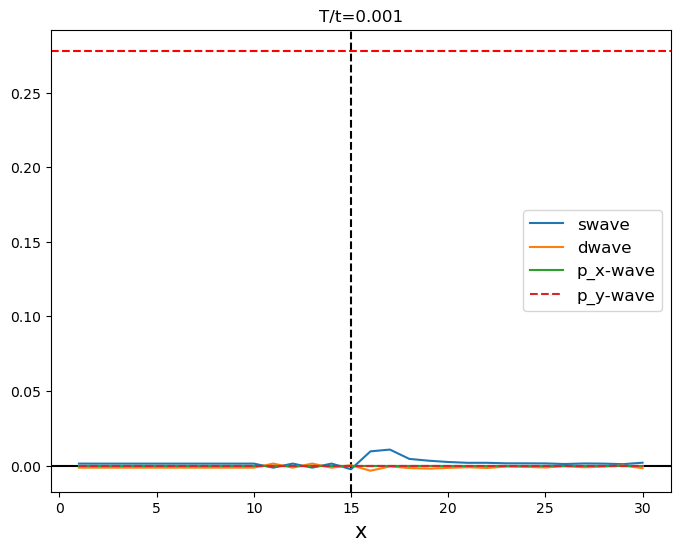

In [5]:
x = np.arange(1, widthN + widthP + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}")
axs.axhline(0, color = 'black')
axs.axvline(widthN, color='black', linestyle='--')
axs.plot(x, np.real(F.swave), label="swave")

axs.plot(x, np.real(F.dwave), label="dwave")
axs.plot(x, np.real(F.px), label="p_x-wave")
axs.plot(x, np.imag(F.py), "--", label="p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.set_xlim(20, 45)
# axs.set_ylim(None, 0.3)
axs.axhline(0.278, linestyle='--', color="red")

axs.legend(fontsize=12, loc="best")
plt.show()

In [6]:
from scripts.utils import is_hermitian

print(is_hermitian(H.build_H_k(np.pi/4)))
print(is_hermitian(H.build_H_kindep()))
print(is_hermitian(H.build_H_k0()))

True
True
True
